In [3]:
import os
from components.broadcast_components.broadcasting_process.broadcast_reporting_utilities import \
    BroadcastMetricGatheringUtilities, plot_stats
import torch
from components.broadcast_components.WZ_models.wz_quant_ANN import WZQuantizer
from components.broadcast_components.WZ_models.wz_quant_RNN import PL_EncoderDecoder_RNN
from components.broadcast_components.broadcasting_process.WZ_broadcast import _test_main, WZBroadcastProtocol
import gzip
import pickle

torch.set_float32_matmul_precision('medium')

import logging
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
import warnings
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX` has been removed")
warnings.filterwarnings("ignore", message="You defined a `validation_step` but have no `val_dataloader`")
warnings.filterwarnings("ignore", message="Consider setting `persistent_workers=True` in 'train_dataloader'")
warnings.filterwarnings("ignore", message="The 'val_dataloader' does not have")

In [4]:
grad_list_rid_wid = []
for rid in range(len(os.listdir('exp_data/save_grads_per_round'))//2):
    grad_list_rid_wid.append([])
    for wid in range(2):
        path_to_file = f'exp_data/save_grads_per_round/grad_round_{rid}_worker_{wid}.pkl.gz'
        with gzip.open(path_to_file, 'rb') as f:
            grad_list_rid_wid[-1].append({k: a.cpu() for k, a in pickle.load(f).items()})

In [5]:
model_shape_dict = {k:v.numpy().shape for k, v in grad_list_rid_wid[0][0].items()}

In [8]:
worker_count = 2

wz_model = PL_EncoderDecoder_RNN(inp_dim=1, side_info_size=0, num_planes=2,
                                 bins_per_plane=4, lr=1e-5).to(torch.float32)
wz_model.load_state_dict(torch.load('../data/basicRNN_2plane_4bins_state.pt', map_location='cpu'))
base_quantizer = WZQuantizer(wz_model, train_sample_size=100_000, count_side_info_data=0, enable_progress_bar=True)
broadcast_prot_base = WZBroadcastProtocol(worker_count, base_quantizer)
broadcast_prot = BroadcastMetricGatheringUtilities(broadcast_prot_base)

for round, grad_per_round in enumerate(grad_list_rid_wid):
    # if round == 2:
    #     break
    for ag_id, grad in enumerate(grad_per_round):
        print(f'>> Round {round}, Agent {ag_id}')
        _ = broadcast_prot.model_transfer_to_worker_from_server(grad)

        print('          - Preparing data for transfer to worker...')
        server_data_sent_to_worker = broadcast_prot.to_worker_prep_data_for_transfer(ag_id)

        print('          - Preparing data for transfer to server...')
        encoded_ag_broadcast = broadcast_prot.to_server_prep_data_for_transfer(
                        ag_id, grad, server_data_sent_to_worker)

        print('          - reconstructing data received...')
        decoded_agent_broadcast = broadcast_prot.reconstruction_process(
            ag_id, encoded_ag_broadcast, worker_count, model_shape_dict)

>> Round 0, Agent 0
          - Preparing data for transfer to worker...
          - Preparing data for transfer to server...
          - reconstructing data received...
>> Round 0, Agent 1
          - Preparing data for transfer to worker...
          - Preparing data for transfer to server...
          - reconstructing data received...
        - training wz model


Training: |          | 0/? [00:00<?, ?it/s]

>> Round 1, Agent 0
          - Preparing data for transfer to worker...
          - Preparing data for transfer to server...
          - reconstructing data received...
        - training wz model


Training: |          | 0/? [00:00<?, ?it/s]

>> Round 1, Agent 1
          - Preparing data for transfer to worker...
          - Preparing data for transfer to server...
          - reconstructing data received...


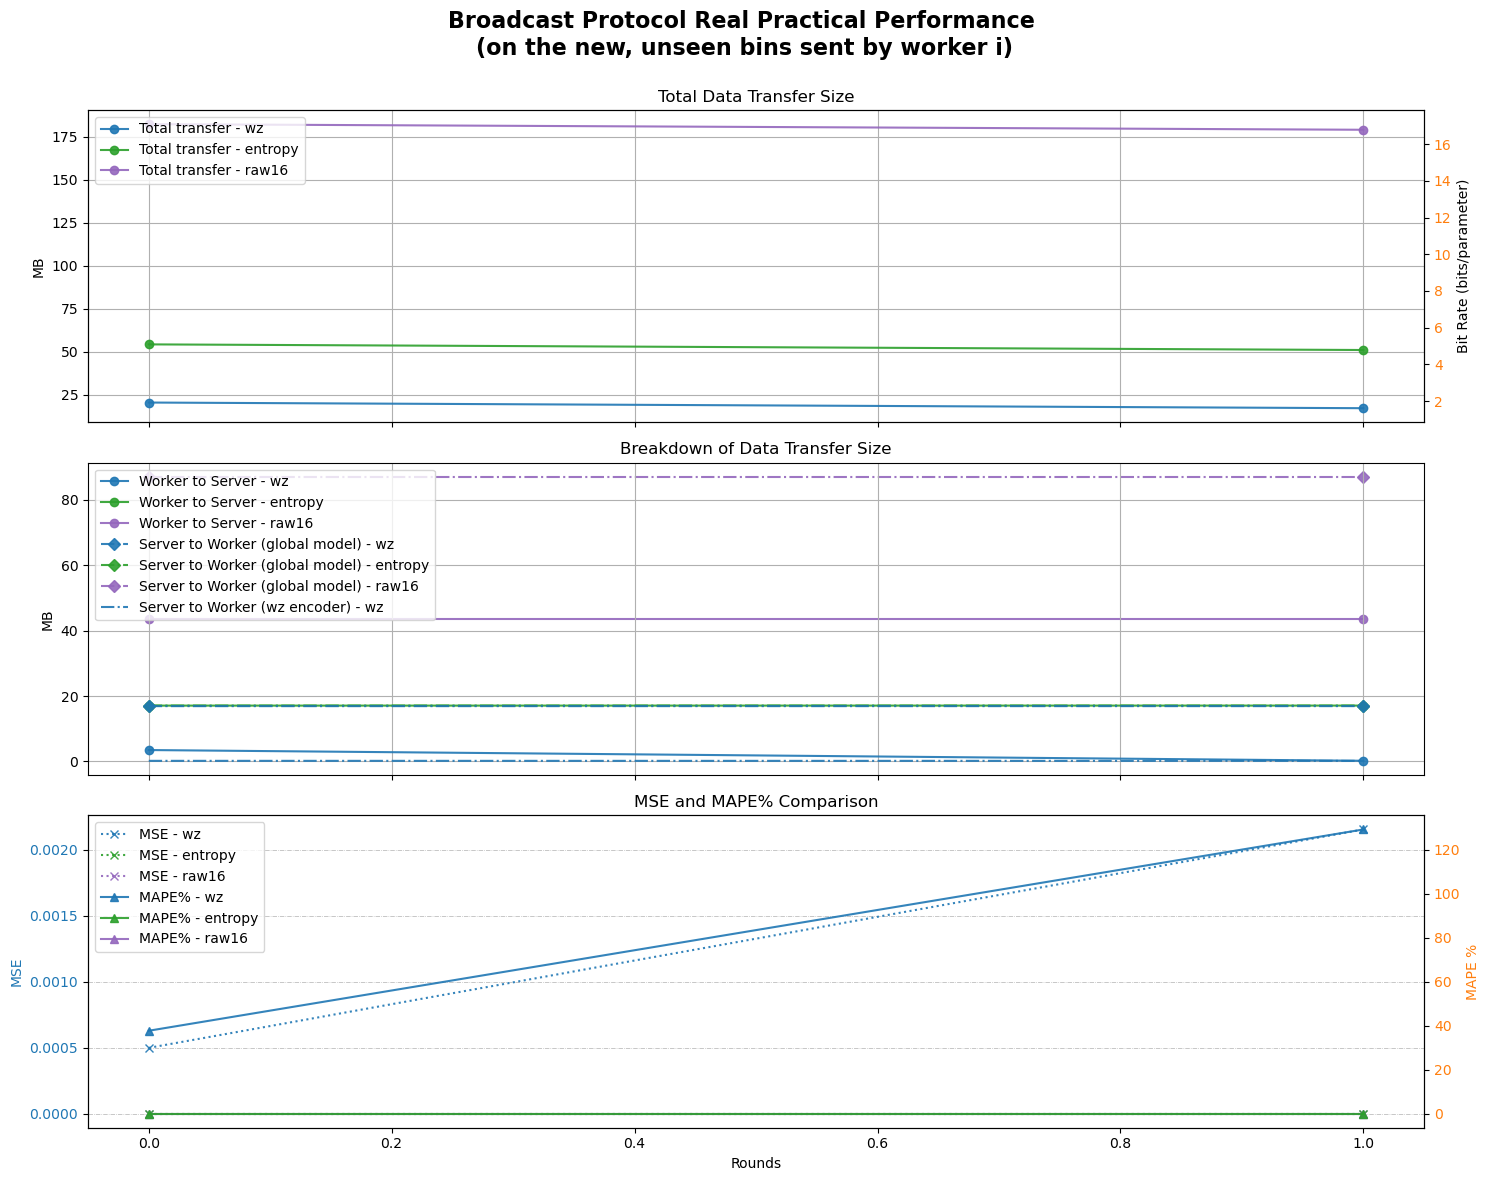

In [9]:
plot_stats(broadcast_prot.entire_stats)